In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

path = "ADNI3_DNA_cleaned.csv"
dna = pd.read_csv(path)
dna["DIAGNOSIS"] = dna["DIAGNOSIS"].fillna(0).astype(int)

In [ ]:
y = dna["DIAGNOSIS"]
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_num = dna.drop(columns=["DIAGNOSIS", "PTID"]).select_dtypes(include=[np.number])
meta = dna[["PTID"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

pca = PCA(n_components=120, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Shape after PCA:", X_pca.shape)

X_train, X_temp, y_train, y_temp, meta_train, meta_temp = train_test_split(
    X_pca, y_encoded, meta, test_size=0.3, stratify=y_encoded, random_state=42
)
X_val, X_test, y_val, y_test, meta_val, meta_test = train_test_split(
    X_temp, y_temp, meta_temp, test_size=0.5, stratify=y_temp, random_state=42
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Shape after PCA: (1112, 120)


VotingClassifier Accuracy: 0.8203592814371258

Classification Report:
               precision    recall  f1-score   support

           1       0.87      0.92      0.89        59
           2       0.83      0.78      0.81        77
           3       0.70      0.74      0.72        31

    accuracy                           0.82       167
   macro avg       0.80      0.81      0.81       167
weighted avg       0.82      0.82      0.82       167



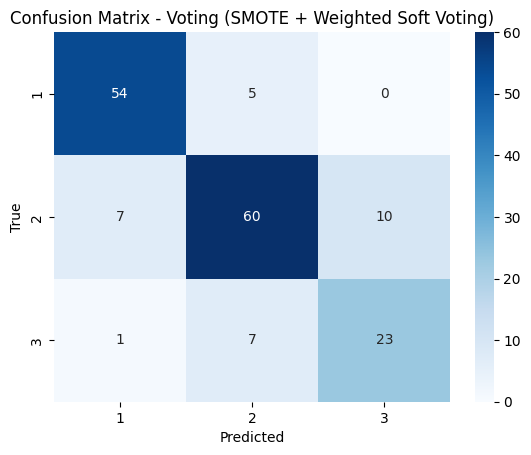

            PTID  True  Pred
1001  006_S_6689     3     3
809   021_S_6978     1     1
473   016_S_6789     2     2
658   016_S_6941     1     1
877   035_S_6950     1     1


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced", random_state=42
)
xgb_clf = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

voting_clf = VotingClassifier(
    estimators=[("rf", rf), ("xgb", xgb_clf)],
    voting="soft",
    weights=[2, 3]
)

voting_clf.fit(X_train_res, y_train_res)

y_pred = voting_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("VotingClassifier Accuracy:", acc)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Voting (SMOTE + Weighted Soft Voting)")
plt.show()

results = meta_test.copy()
results["True"] = le.inverse_transform(y_test)
results["Pred"] = le.inverse_transform(y_pred)
print(results.head())

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

f1_macro = make_scorer(f1_score, average="macro")

param_grid_rf = {
    "n_estimators": [200, 300, 400],
    "max_depth": [6, 8, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": ["balanced"]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring=f1_macro,
    cv=3,
    n_jobs=-1
)

grid_rf.fit(X_train_res, y_train_res)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF Macro-F1:", grid_rf.best_score_)

Best RF Params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF Macro-F1: 0.8661724238342084


In [ ]:
best_rf = grid_rf.best_estimator_

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.7, 0.9]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train_res, y_train_res)

print("Best XGB Params:", grid_xgb.best_params_)
print("Best XGB Macro-F1:", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_

Fitting 3 folds for each of 128 candidates, totalling 384 fits
Best XGB Params: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 500, 'subsample': 0.8}
Best XGB Macro-F1: 0.8826178203871855
Fitting 3 folds for each of 128 candidates, totalling 384 fits
Best XGB Params: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 500, 'subsample': 0.8}
Best XGB Macro-F1: 0.8826178203871855


In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Evaluate individual models
rf_val_pred = best_rf.predict(X_val)
xgb_val_pred = best_xgb.predict(X_val)

rf_f1 = f1_score(y_val, rf_val_pred, average="macro")
xgb_f1 = f1_score(y_val, xgb_val_pred, average="macro")

print("RF F1:", rf_f1)
print("XGB F1:", xgb_f1)

# Normalize weights
weights = np.array([rf_f1, xgb_f1])
weights = weights / weights.sum()

print("Voting Weights (RF, XGB):", weights)

RF F1: 0.8342094444596705
XGB F1: 0.8386055495500897
Voting Weights (RF, XGB): [0.49868602 0.50131398]
RF F1: 0.8342094444596705
XGB F1: 0.8386055495500897
Voting Weights (RF, XGB): [0.49868602 0.50131398]


Voting Ensemble Accuracy: 0.8263473053892215

Classification Report:
               precision    recall  f1-score   support

           1       0.90      0.92      0.91        59
           2       0.83      0.81      0.82        77
           3       0.69      0.71      0.70        31

    accuracy                           0.83       167
   macro avg       0.80      0.81      0.81       167
weighted avg       0.83      0.83      0.83       167



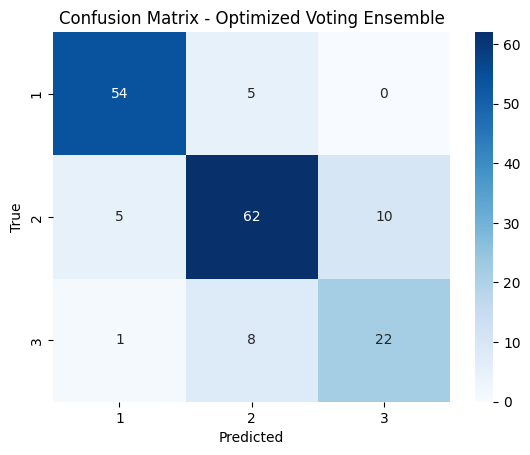

Voting Ensemble Accuracy: 0.8263473053892215

Classification Report:
               precision    recall  f1-score   support

           1       0.90      0.92      0.91        59
           2       0.83      0.81      0.82        77
           3       0.69      0.71      0.70        31

    accuracy                           0.83       167
   macro avg       0.80      0.81      0.81       167
weighted avg       0.83      0.83      0.83       167



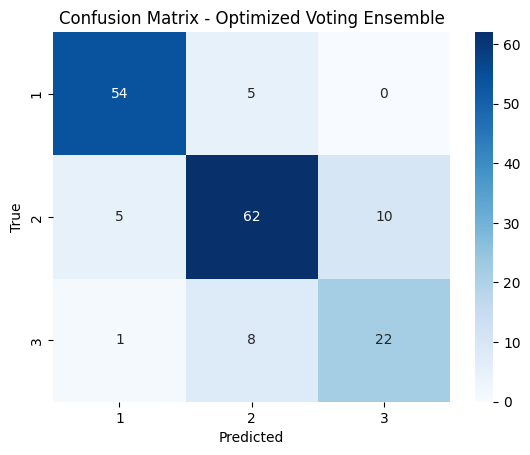

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

voting_model = VotingClassifier(
    estimators=[("rf", best_rf), ("xgb", best_xgb)],
    voting="soft",
    weights=weights
)

voting_model.fit(X_train_res, y_train_res)
y_pred = voting_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Voting Ensemble Accuracy:", acc)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Optimized Voting Ensemble")
plt.show()

MLP Accuracy: 0.8023952095808383

Classification Report:
               precision    recall  f1-score   support

           1       0.91      0.88      0.90        59
           2       0.82      0.77      0.79        77
           3       0.61      0.74      0.67        31

    accuracy                           0.80       167
   macro avg       0.78      0.80      0.79       167
weighted avg       0.81      0.80      0.81       167



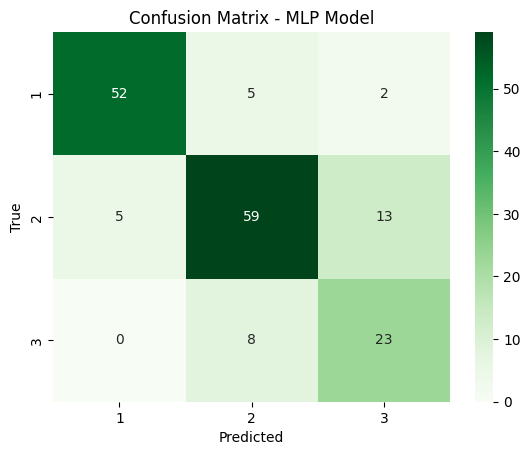

MLP Accuracy: 0.8023952095808383

Classification Report:
               precision    recall  f1-score   support

           1       0.91      0.88      0.90        59
           2       0.82      0.77      0.79        77
           3       0.61      0.74      0.67        31

    accuracy                           0.80       167
   macro avg       0.78      0.80      0.79       167
weighted avg       0.81      0.80      0.81       167



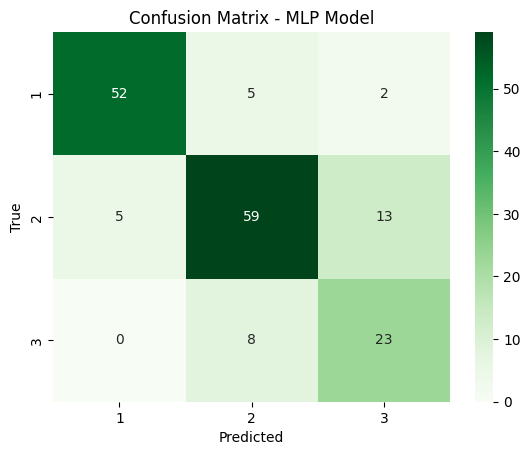

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)
mlp.fit(X_train_res, y_train_res)

y_pred_mlp = mlp.predict(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
print("MLP Accuracy:", acc_mlp)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_mlp, target_names=[str(c) for c in le.classes_]))

cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - MLP Model")
plt.show()


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

mlp = MLPClassifier(
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42,
    early_stopping=True
)

param_grid_mlp = {
    "hidden_layer_sizes": [
        (128,),
        (256,),
        (256, 128),
        (256, 128, 64)
    ],
    "learning_rate_init": [0.0005, 0.001, 0.005],
    "alpha": [0.0001, 0.001, 0.01]
}

grid_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_mlp.fit(X_train_res, y_train_res)

print("Best MLP Params:", grid_mlp.best_params_)
print("Best MLP Macro-F1:", grid_mlp.best_score_)

best_mlp = grid_mlp.best_estimator_


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best MLP Params: {'alpha': 0.0001, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.005}
Best MLP Macro-F1: 0.8599476674581544
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best MLP Params: {'alpha': 0.0001, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.005}
Best MLP Macro-F1: 0.8599476674581544


Best MLP Test Accuracy: 0.7964071856287425

Classification Report:
               precision    recall  f1-score   support

           1       0.85      0.88      0.87        59
           2       0.82      0.77      0.79        77
           3       0.65      0.71      0.68        31

    accuracy                           0.80       167
   macro avg       0.77      0.79      0.78       167
weighted avg       0.80      0.80      0.80       167



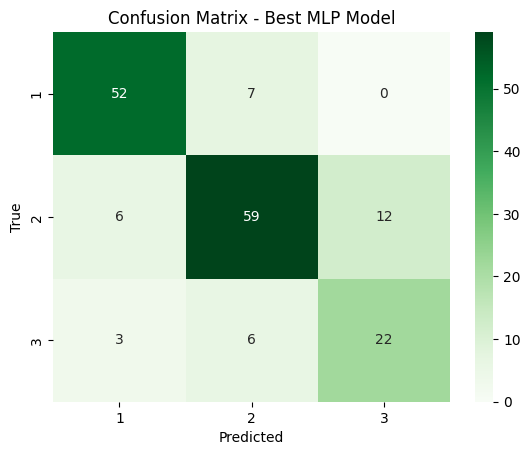

Best MLP Test Accuracy: 0.7964071856287425

Classification Report:
               precision    recall  f1-score   support

           1       0.85      0.88      0.87        59
           2       0.82      0.77      0.79        77
           3       0.65      0.71      0.68        31

    accuracy                           0.80       167
   macro avg       0.77      0.79      0.78       167
weighted avg       0.80      0.80      0.80       167



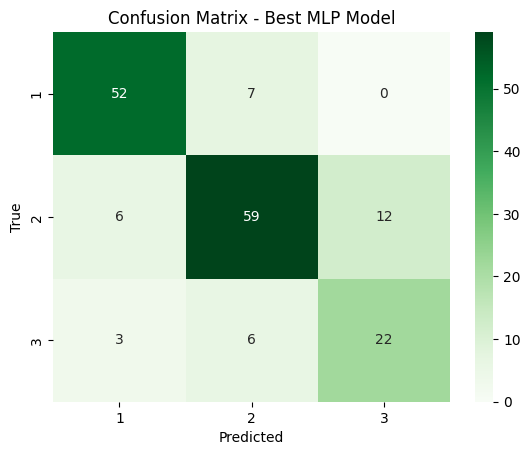

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_mlp = best_mlp.predict(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
print("Best MLP Test Accuracy:", acc_mlp)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_mlp, target_names=[str(c) for c in le.classes_]))

cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Best MLP Model")
plt.show()

SVM Accuracy: 0.7724550898203593

Classification Report:
               precision    recall  f1-score   support

           1       0.86      0.86      0.86        59
           2       0.80      0.71      0.75        77
           3       0.59      0.74      0.66        31

    accuracy                           0.77       167
   macro avg       0.75      0.77      0.76       167
weighted avg       0.78      0.77      0.77       167



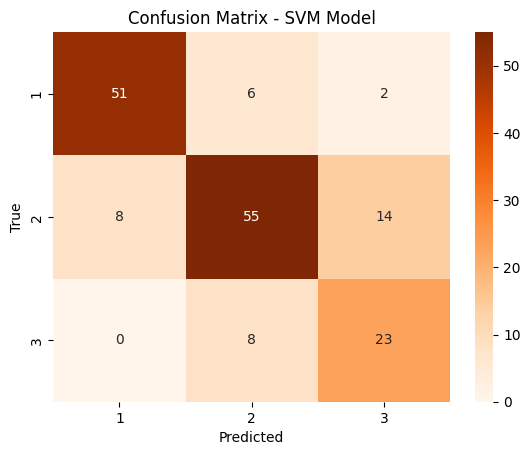

In [ ]:
svm_clf = SVC(
    kernel="rbf",
    C=2.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_clf.fit(X_train_res, y_train_res)

y_pred_svm = svm_clf.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", acc_svm)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_svm, target_names=[str(c) for c in le.classes_]))

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - SVM Model")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

param_grid_svm = {
    "C": [0.1, 1, 2, 5, 10],
    "gamma": ["scale", 0.01, 0.001, 0.0001]
}

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train_res, y_train_res)

print("Best SVM Params:", grid_svm.best_params_)
print("Best SVM Macro-F1 (CV):", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best SVM Params: {'C': 10, 'gamma': 'scale'}
Best SVM Macro-F1 (CV): 0.88222215378861


Best SVM Test Accuracy: 0.8263473053892215

Classification Report:
               precision    recall  f1-score   support

           1       0.92      0.92      0.92        59
           2       0.82      0.81      0.81        77
           3       0.69      0.71      0.70        31

    accuracy                           0.83       167
   macro avg       0.81      0.81      0.81       167
weighted avg       0.83      0.83      0.83       167



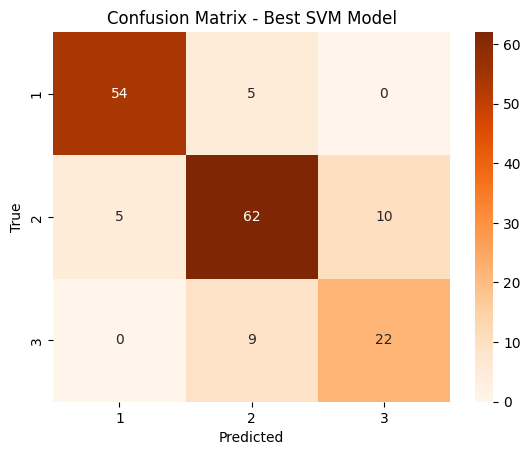

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_svm = best_svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
print("Best SVM Test Accuracy:", acc_svm)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_svm, target_names=[str(c) for c in le.classes_]))

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Best SVM Model")
plt.show()

Random Forest Accuracy: 0.8383233532934131

Classification Report:
               precision    recall  f1-score   support

           1       0.92      0.92      0.92        59
           2       0.82      0.83      0.83        77
           3       0.73      0.71      0.72        31

    accuracy                           0.84       167
   macro avg       0.82      0.82      0.82       167
weighted avg       0.84      0.84      0.84       167



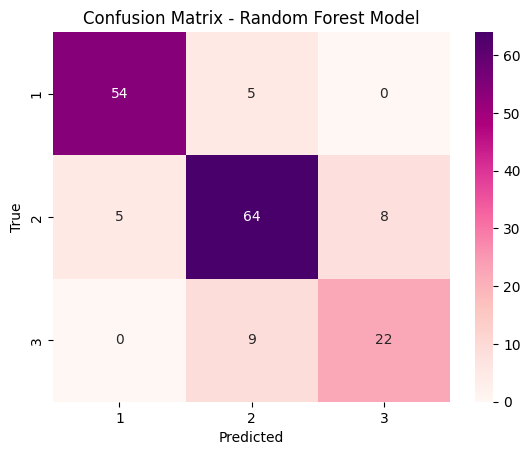

Random Forest Accuracy: 0.8383233532934131

Classification Report:
               precision    recall  f1-score   support

           1       0.92      0.92      0.92        59
           2       0.82      0.83      0.83        77
           3       0.73      0.71      0.72        31

    accuracy                           0.84       167
   macro avg       0.82      0.82      0.82       167
weighted avg       0.84      0.84      0.84       167



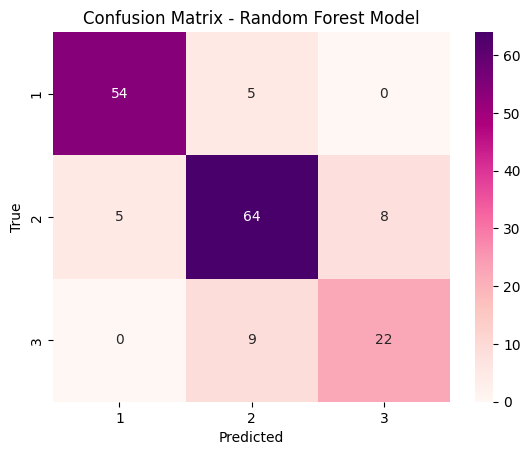

In [ ]:
# Random Forest Model
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
rf_clf.fit(X_train_res, y_train_res)

# Predict
y_pred_rf = rf_clf.predict(X_test)

# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

# Classification Report
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_rf, target_names=[str(c) for c in le.classes_]))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="RdPu",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Random Forest Model")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

param_grid_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train_res, y_train_res)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF Macro-F1 (CV):", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

Fitting 3 folds for each of 288 candidates, totalling 864 fits
Best RF Params: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best RF Macro-F1 (CV): 0.8816203042415668


Best RF Test Accuracy: 0.8263473053892215

Classification Report:
               precision    recall  f1-score   support

           1       0.90      0.88      0.89        59
           2       0.81      0.83      0.82        77
           3       0.73      0.71      0.72        31

    accuracy                           0.83       167
   macro avg       0.81      0.81      0.81       167
weighted avg       0.83      0.83      0.83       167



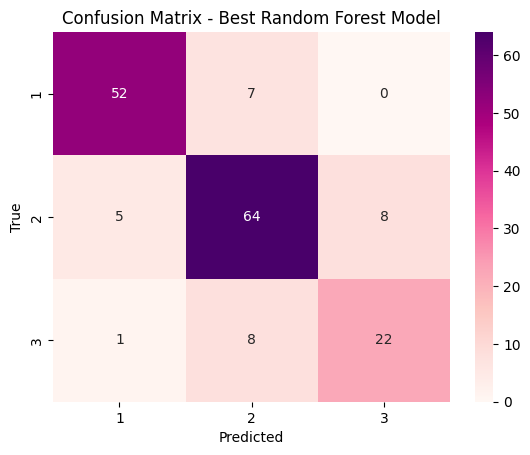

In [ ]:
# Predict with best model
y_pred_rf_best = best_rf.predict(X_test)

acc_rf_best = accuracy_score(y_test, y_pred_rf_best)
print("Best RF Test Accuracy:", acc_rf_best)

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_rf_best, target_names=[str(c) for c in le.classes_]))

cm_rf_best = confusion_matrix(y_test, y_pred_rf_best)
sns.heatmap(cm_rf_best, annot=True, fmt="d", cmap="RdPu",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Best Random Forest Model")
plt.show()

In [ ]:
from sklearn.metrics import f1_score

results = pd.DataFrame({
    "Model": ["voting", "SVM", "MLP","RandomForest"],
    "Accuracy": [acc, acc_svm, acc_mlp,acc_rf_best],
    "Macro F1": [
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test, y_pred_svm, average="macro"),
        f1_score(y_test, y_pred_mlp, average="macro"),
        f1_score(y_test, y_pred_rf_best, average="macro")
    ]
})
print(results)

          Model  Accuracy  Macro F1
0        voting  0.826347  0.807255
1           SVM  0.826347  0.808041
2           MLP  0.796407  0.778512
3  RandomForest  0.826347  0.810238
